In [ ]:
# Healthcare Data Analysis

## Objective
#Explore and preprocess a healthcare dataset to prepare it for analysis and machine learning.

In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("healthcare_dataset.csv")

# Display first 5 rows
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [ ]:
# Data Cleaning
#Standardizing column names for easier usage.

In [2]:
df.columns = df.columns.str.replace(" ", "_")
df.columns

Index(['Name', 'Age', 'Gender', 'Blood_Type', 'Medical_Condition',
       'Date_of_Admission', 'Doctor', 'Hospital', 'Insurance_Provider',
       'Billing_Amount', 'Room_Number', 'Admission_Type', 'Discharge_Date',
       'Medication', 'Test_Results'],
      dtype='object')

In [ ]:
# Data Types
# Identifying numerical and categorical variables.

In [3]:
df.dtypes

Name                   object
Age                     int64
Gender                 object
Blood_Type             object
Medical_Condition      object
Date_of_Admission      object
Doctor                 object
Hospital               object
Insurance_Provider     object
Billing_Amount        float64
Room_Number             int64
Admission_Type         object
Discharge_Date         object
Medication             object
Test_Results           object
dtype: object

In [ ]:
# Descriptive Statistics
#Analyzing numerical features.

In [4]:
df.describe()

,Age,Billing_Amount,Room_Number
count,55500.000000,55500.000000,55500.000000
mean,51.539459,25539.316097,301.134829
std,19.602454,14211.454431,115.243069
min,13.000000,-2008.492140,101.000000
25%,35.000000,13241.224652,202.000000
50%,52.000000,25538.069376,302.000000
75%,68.000000,37820.508436,401.000000
max,89.000000,52764.276736,500.000000


In [ ]:
#Billing_Amount has the highest mean and variance.

In [5]:
df.var(numeric_only=True)

Age               3.842562e+02
Billing_Amount    2.019654e+08
Room_Number       1.328096e+04
dtype: float64

In [ ]:
# Missing Values
#Checking for missing data.

In [6]:
df.isnull().sum()

Name                  0
Age                   0
Gender                0
Blood_Type            0
Medical_Condition     0
Date_of_Admission     0
Doctor                0
Hospital              0
Insurance_Provider    0
Billing_Amount        0
Room_Number           0
Admission_Type        0
Discharge_Date        0
Medication            0
Test_Results          0
dtype: int64

In [ ]:
#There are no missing values in the dataset.

In [ ]:
# Categorical Analysis
#Analyzing Admission Type.

In [7]:
df['Admission_Type'].value_counts()

Admission_Type
Elective     18655
Urgent       18576
Emergency    18269
Name: count, dtype: int64

In [ ]:
#There are 3 categories: Elective, Urgent, Emergency.

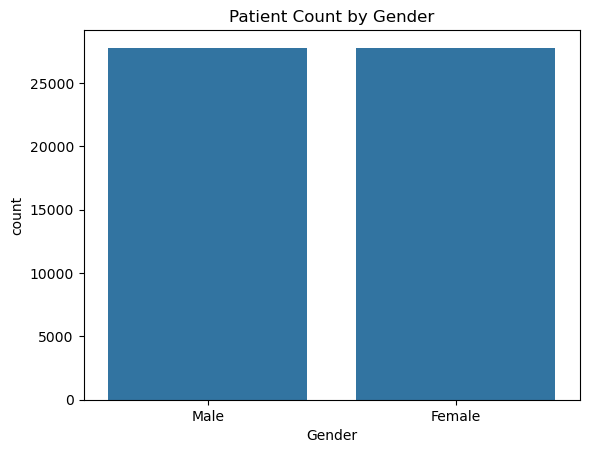

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Gender', data=df)
plt.title("Patient Count by Gender")
plt.show()

In [ ]:
#The gender distribution is approximately even.

In [ ]:
# Feature Engineering
#Creating dummy variables.

In [9]:
df_dummies = pd.get_dummies(df, columns=[
    'Test_Results',
    'Medical_Condition',
    'Admission_Type'
])

df_dummies.shape

(55500, 24)

In [ ]:
#The number of columns increased after encoding categorical variables.

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df['Age_scaled'] = scaler.fit_transform(df[['Age']])

df['Age_scaled'].mean(), df['Age_scaled'].std()

(np.float64(7.783963663822359e-17), 1.0000090091307399)

In [ ]:
#Age is normalized with mean ~0 and standard deviation ~1.

In [11]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df_dummies, test_size=0.3, random_state=42)

train.shape[0], test.shape[0]

(38850, 16650)

In [ ]:
#Dataset split into 70% training and 30% testing.

In [ ]:
# Conclusion

#- Dataset contains no missing values
#- Billing amount has highest variance
#- Gender distribution is balanced
#- Data successfully prepared for machine learning

#This project demonstrates data cleaning, exploration, and preprocessing.